# **ZADANIE PRAKTYCZNE - wykonane w trakcie cwiczen**

## IMIE: Małgorzata
## NAZWISKO: Bondini

## WAZNE: prosze zmienic nazwe notatnika na: "Nazwisko_Imie_MAD_ZadaniePraktyczne01"

## BARDZO WAZNE: NALEZY PRZESLAC ZADANIE NA PORTALU OKNO ABY UZYSKAC ZALICZENIE !







## __ZADANIE: Zbuduj model klasyfikacyjny do rozróżniania między nowotworami złośliwymi a łagodnymi dla zbioru danych dotyczącego raka piersi__

## __Wykonaj nastepujace podzadania w swoim rozwiazaniu__

1. __Załaduj i zbadaj zbiór danych:__
  * TIP: jako was "zleceniodawca" dostarczyłem dane w pierwszej komorce kodu     
  * Wyświetl pierwsze kilka wierszy zbioru danych
  * Wyświetl statystyki opisowe zbioru danych
  * Wypisz liczbę przykładów dla każdej klasy
  * PYTANIE: czy zestaw danych jest zbalansowany?

2. __Przygotoj dane__
  * Wydziel zbiór testowy i treningowy, - zastanow sie czy musisz użyc stratycikacji
  * przeskaluj dane,
  * PYTANIE: czy zestawy treningowy i testowy maja odpowiednie porporcje klas i czy sa takie same jak we wszystkich danych przed podziałem

3. __Oblicz średnią dokładność przy użyciu walidacji krzyżowej dla modeli:__  
  * Regresja logistyczna z regularizacją LASSO, C = 1, 0.5, 0.01
  * Pełne Drzewo decyzyjne
  * Las losowy z parametrami: n_estimators = 100, 200

4. __Porównaj wyniki, wybierz najlepszy model, wytrenoj go ponownie na wszystkich danych treningowych, i oblicz dokładność dla zbioru testowego.__  
  * zaraportuj wyniki

5. __Narysuj macierz pomyłek dla najlepszego modelu na zbiorze testowym__


### NOTATKI: Informacje o zbiorze danych dotyczącego raka piersi
Zbiór danych dotyczący raka piersi jest dobrze znanym zbiorem danych używanym w zadaniach klasyfikacji binarnej. Zawiera cechy obliczone na podstawie zdigitalizowanych obrazów aspiracji cienkoigłowej (FNA) mas piersi. Celem jest klasyfikacja nowotworów jako złośliwych lub łagodnych.
Opis zbioru danych dotyczącego raka piersi
Liczba instancji: 569
Liczba atrybutów: 30 numerycznych, predykcyjnych atrybutów oraz etykieta klasy
Etykieta klasy: Etykieta klasy wskazuje, czy nowotwór jest złośliwy (0) czy łagodny (1).



---



## **ZANIM ZACZNIECIE KODOWAC ODPOWIEDZCIE SOBIE NA TE PYTANIA**
"uporzadkujcie swoj projekt, przykladowe pytania i zagadnienia sa pod kazdym punktem"

* __jakie sa pytania lub zadania?__
* __jakie mamy dane?__
* __jakiego modelu chcecie uzyc?__
* __jak wykonac trenowanie?__
* __jak wykonamy podsumowanie?__


## **ML workflow**
* 01. Load the data
* 02. Explore the data (dimensionality, class number, value range, value types, other questions)
* 03. Define how to Clean/transform the data (missing data, duplicates, clipping values, binarization, one-hot encoding, etc.)
* 04. Model training
  * a) Prepare the data (split into training and testing datasets)
  * b) Train the model (e.g., use: sklearn package, fit, predict, methods)
  * c) Evaluate the model (score, statistics like sensitivity, specificity, F1, ROC-AUC, reference model - baseline, confusion matrix)
* 05. Compare multiple models with each other
* 06. create summary and asnwer questions

## **TIPs**
- Regression: use R^2 (score method)
- Classification: use Accuracy (score method)
- Logistic regression with L1: solver = "liblinear"


In [1]:
# Coding tip No 1: How to save results from different models
import pandas as pd

results = list()

results.append({
    "model_name":"model1 results",
    "acc":0.8})
results.append({
    "model_name":"model2 results",
    "acc":0.95})
results.append({
    "model_name":"model2 results",
    "acc":0.62})

pd.DataFrame(results).sort_values(by="acc", ascending=False)

,model_name,acc
1,model2 results,0.95
0,model1 results,0.80
2,model2 results,0.62


## **KODOWANIE**

In [2]:
"""
### Order of things
* Imports
* Load the data
* Find ( X ), ( y )
* Explore ( X ) and ( y )
* Format ( X ) and ( y ), EG, AS INTEGERS, alwasy try to make it work with min. work, later on, make it more complicicated
* scale if needed, add or remove missing data , USE PILEINE IF NEEDED,
* Split into test and train sets
* List models you will use and all their parameters that you wish to modify
* Train models one by one and evaluate using cross-validation
* Select the best model
* retrain best performing model with all the train data (so far these were used for cross validation)
* Evaluate on the test data
* Report the results
"""

'\n### Order of things\n* Imports\n* Load the data\n* Find ( X ), ( y )\n* Explore ( X ) and ( y )\n* Format ( X ) and ( y ), EG, AS INTEGERS, alwasy try to make it work with min. work, later on, make it more complicicated\n* scale if needed, add or remove missing data , USE PILEINE IF NEEDED,\n* Split into test and train sets\n* List models you will use and all their parameters that you wish to modify\n* Train models one by one and evaluate using cross-validation\n* Select the best model\n* retrain best performing model with all the train data (so far these were used for cross validation)\n* Evaluate on the test data\n* Report the results\n'

In [1]:
%pip install scikit-learn

# load data
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

# find X and y
X = cancer.data
y = cancer.target

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **PYTATANIE PRZED - ANALIZA ZBIORU**

### 1. **Jakie są pytania lub zadania?**

**Główne zadanie:**
- Zbudować model klasyfikacyjny do rozróżniania między nowotworami złośliwymi a łagodnymi

**Pytania do rozwiązania:**
- Czy zestaw danych jest zbalansowany?
- Czy zestawy treningowy i testowy mają odpowiednie proporcje klas?
- Który model klasyfikacyjny osiąga najlepszą dokładność?

**podzadania:**
1. Przygotować dane (podział + skalowanie)
2. Przetestować 6 modeli z walidacją krzyżową
3. Wybrać najlepszy model i ocenić na zbiorze testowym
4. Stworzyć macierz

### 2. **Jakie mamy dane?**

- Breast Cancer Wisconsin
- Zmienna binarna
  - 0 = złośliwy
  - 1 = łagodnY
- Dane numeryczne

### 3. **Jakiego modelu chcecie użyć?**

**Modele do przetestowania:**

1. Regresja Logistyczna LASSO
2. Pełne Drzewo Decyzyjne
3. Las Losowy (EWENTUALNIE); bardziej odporny na przeuczenie niż pojedyncze drzewo

### 4. **Jak wykonać trenowanie?**

**Przygotowanie danych**
- Podział na treningowe i testowe

**Walidacja krzyżowa**
- Dane: tylko zbiór treningowy

**Wybór najlepszego modelu**
- Wybór modelu z najwyższą średnią dokładnością

**Trenowanie**
- Retrenowanie najlepszego modelu na CAŁYM zbiorze treningowym
- Ocena na zbiorze testowym

### 5. **Podsumowanie**

A. Porównanie modeli (np. co do dokładności)

B. Wybranie ajlepszego modelu (np. czy dobrze generalizuje)

C. Szczegółowa ocena i interpretacja (np. metryk)

D. Wnioski końcowe np: 
- Który model jest najlepszy i dlaczego
- Jak dobrze model radzi sobie z klasyfikacją

## Test, czy dataset się załadował poprawnie

In [4]:
type(cancer)

sklearn.utils._bunch.Bunch

In [5]:
X.shape, y.shape

((569, 30), (569,))

In [32]:
type(X)

X = pd.DataFrame(X)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [33]:
X.describe ()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [34]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [35]:
y.shape

(569,)

In [6]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')
print("="*80)
df = X.copy()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Analiza zbioru

In [ ]:
%pip install scikit-learn

from sklearn.model_selection import train_test_split
# Podział danych na zbiór treningowy i testowy - w tym przyp[adku używamy stratyfikacji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)
print(f"Rozmiar zbioru treningowego X_train: {X_train.shape}")
print(f"Rozmiar zbioru testowego X_test: {X_test.shape}")
print(f"Rozmiar zbioru treningowego y_train: {y_train.shape}")
print(f"Rozmiar zbioru testowego y_test: {y_test.shape}")

Rozmiar zbioru treningowego X_train: (455, 30)
Rozmiar zbioru testowego X_test: (114, 30)
Rozmiar zbioru treningowego y_train: (455,)
Rozmiar zbioru testowego y_test: (114,)


In [37]:
print('cały zbiór:')
display(pd.Series(y).value_counts(normalize=True))

print('zbiór treningowy:')
display(pd.Series(y_train).value_counts(normalize=True))

print('zbiór testowy:')
display(pd.Series(y_test).value_counts(normalize=True))

cały zbiór:


target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

zbiór treningowy:


target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

zbiór testowy:


target
1    0.631579
0    0.368421
Name: proportion, dtype: float64

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix

# setup
results = list()

# load data
cancer = load_breast_cancer()

# find X and y
X = cancer.data
y = cancer.target

# Podzial danych na zbiór treningowy i testowy - w tym przypadku używamy stratyfikacji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

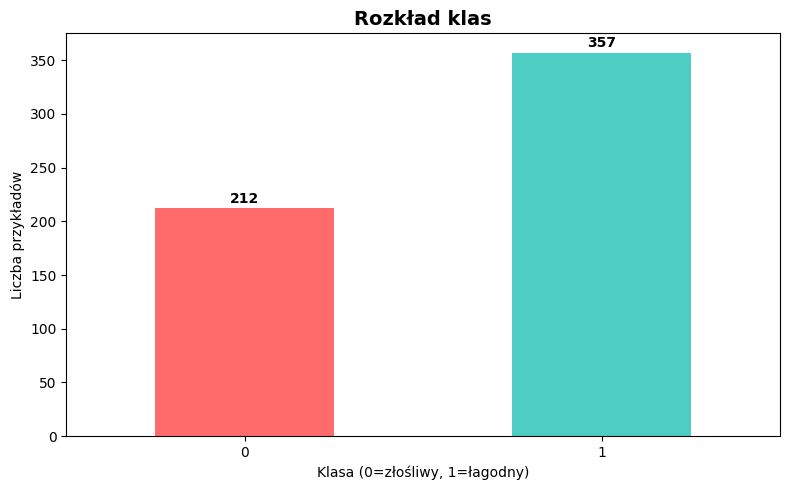

In [8]:
import matplotlib.pyplot as plt
class_counts = y.value_counts().sort_index()
total = len(y)
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Rozkład klas', fontsize=14, fontweight='bold')
plt.xlabel('Klasa (0=złośliwy, 1=łagodny)')
plt.ylabel('Liczba przykładów')
plt.xticks(rotation=0)
for i, v in enumerate(class_counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

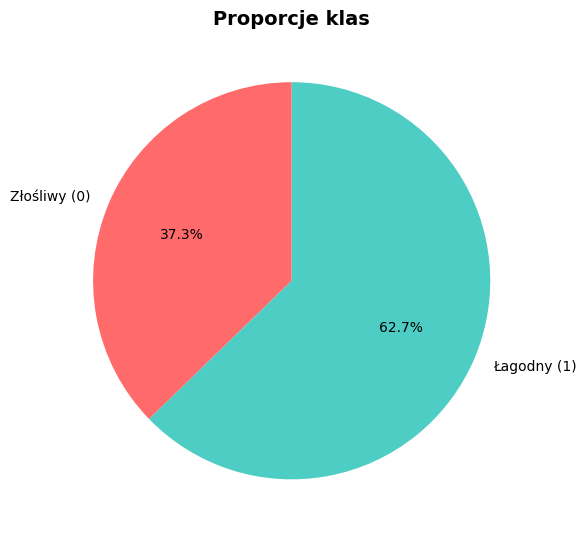

In [9]:
# Wykres kołowy
colors = ['#FF6B6B', '#4ECDC4']
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    class_counts.values,
    labels=['Złośliwy (0)', 'Łagodny (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title('Proporcje klas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
ratio = class_counts[0] / class_counts[1]
print(f"Proporcja: {class_counts[1]}:{class_counts[0]} (łagodny:złośliwy)")

if 0.8 <= ratio <= 1.2:
    print("Zbiór jest zbalansowany")
else:
    print("Zbiór jest umiarkowanie niezbalansowany lub niezbalansowany")

Proporcja: 357:212 (łagodny:złośliwy)
Zbiór jest umiarkowanie niezbalansowany lub niezbalansowany


Zestaw danych jest **umiarkowanie niezbalansowany**: 
- Klasa 1 (łagodny) ma około 63% próbek
- Klasa 0 (złośliwy) ma około 37% próbek

- **Warto zachować stratyfikację przy podziale train/test**

Decyzja: używamy stratyfikacji, żeby zachować proporcję w train/test

In [11]:
#wykład

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=15, stratify=y
)
print(f"Rozmiar zbioru treningowego X_train: {X_train.shape}")
print(f"Rozmiar zbioru testowego X_test: {X_test.shape}")
print(f"Rozmiar zbioru treningowego y_train: {y_train.shape}")
print(f"Rozmiar zbioru testowego y_test: {y_test.shape}")

Rozmiar zbioru treningowego X_train: (455, 30)
Rozmiar zbioru testowego X_test: (114, 30)
Rozmiar zbioru treningowego y_train: (455,)
Rozmiar zbioru testowego y_test: (114,)


In [12]:
#wykład
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Stratyfikacja zadziałała. Proporcje są prawie identyczne:
print('cały zbiór:')
s = pd.Series(y).value_counts()
display(pd.DataFrame({'liczba': s.values, 'udział %': (s / len(y) * 100).round(2).values}, index=s.index))

print('zbiór treningowy:')
s = pd.Series(y_train).value_counts()
display(pd.DataFrame({'liczba': s.values, 'udział %': (s / len(y_train) * 100).round(2).values}, index=s.index))

print('zbiór testowy:')
s = pd.Series(y_test).value_counts()
display(pd.DataFrame({'liczba': s.values, 'udział %': (s / len(y_test) * 100).round(2).values}, index=s.index))

cały zbiór:


,liczba,udział %
target,,
1,357,62.74
0,212,37.26


zbiór treningowy:


,liczba,udział %
target,,
1,285,62.64
0,170,37.36


zbiór testowy:


,liczba,udział %
target,,
1,72,63.16
0,42,36.84


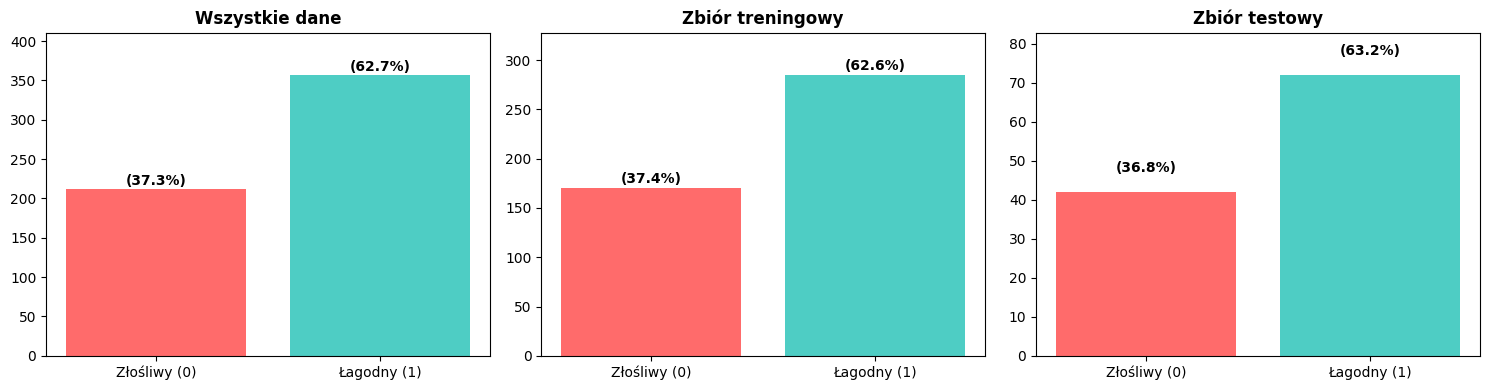

Proporcje są zachowane


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (data_y, title) in zip(axes, [
    (y,       'Wszystkie dane'),
    (y_train, 'Zbiór treningowy'),
    (y_test,  'Zbiór testowy')
]):
    counts = data_y.value_counts().sort_index()
    ax.set_ylim(0, counts.values.max() * 1.15)
    ax.bar(['Złośliwy (0)', 'Łagodny (1)'], counts.values, color=['#FF6B6B', '#4ECDC4'])
    ax.set_title(title, fontweight='bold')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, f'({v/len(data_y)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Proporcje są zachowane")

# teoria

Dzięki użyciu parametru `stratify=y` w funkcji `train_test_split`:

- **Wszystkie dane**: ~37% klasa 0, ~63% klasa 1
- **Zbiór treningowy**: ~37% klasa 0, ~63% klasa 1  
- **Zbiór testowy**: ~37% klasa 0, ~63% klasa 1

**Proporcje są praktycznie identyczne** we wszystkich zbiorach, co oznacza że:
1. Stratyfikacja zadziałała poprawnie
2. Model będzie trenowany na reprezentatywnych danych
3. Wyniki na zbiorze testowym będą wiarygodne i porównywalne

## Skalowanie danych: 

In [15]:
# transformacja danych treningowych
X_train_scaled = scaler.fit_transform(X_train)

# transformacja danych testowych
X_test_scaled = scaler.transform(X_test)

print(f"   X_train_scaled: {X_train_scaled.shape}")
print(f"   X_test_scaled: {X_test_scaled.shape}")
print(f"   Przed skalowaniem: {X_train.iloc[:, 0].mean():.2f}, std: {X_train.iloc[:, 0].std():.2f}")
print(f"   Po skalowaniu: {X_train_scaled[:, 0].mean():.2f}, std: {X_train_scaled[:, 0].std():.2f}")

   X_train_scaled: (455, 30)
   X_test_scaled: (114, 30)
   Przed skalowaniem: 14.07, std: 3.47
   Po skalowaniu: -0.00, std: 1.00


## TRENING I WALIDACJA MODELI

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix

In [16]:
# Regresja Logistyczna z regularyzacją LASSO

from sklearn.linear_model import LogisticRegression # type: ignore
model_etap1 = LogisticRegression(C=1, l1_ratio=1, solver='saga', random_state=42, max_iter=5000)

model_etap1.fit(X_train_scaled, y_train)

# na zbiorze treningowym osonmo
train_score = model_etap1.score(X_train_scaled, y_train)
print(f"Dokładność na zbiorze treningowym: {train_score:.4f}")

# na zbiorze testowym osobno
test_score = model_etap1.score(X_test_scaled, y_test)
print(f"Dokładność na zbiorze testowym: {test_score:.4f}")

Dokładność na zbiorze treningowym: 0.9890
Dokładność na zbiorze testowym: 0.9825


In [45]:
# Drzewo decyzyjne
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

if "results_list" not in globals():
    results_list = []

dt_model = DecisionTreeClassifier(random_state=42)
dt_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

results_list.append({
    'model_name': 'Decision Tree',
    'mean_accuracy': dt_scores.mean(),
    'std_accuracy': dt_scores.std()
})

print(f"\n🌳 Drzewo Decyzyjne: {dt_scores.mean():.4f} (+/- {dt_scores.std():.4f})")


🌳 Drzewo Decyzyjne: 0.9231 (+/- 0.0231)


In [44]:
# 2. Pełne Drzewo Decyzyjne
dt_model = DecisionTreeClassifier(random_state=42)
dt_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

results_list.append({
    'model_name': 'Decision Tree (pełne)',
    'mean_accuracy': dt_scores.mean(),
    'std_accuracy': dt_scores.std()
})

print(f"\n🌳 Pełne Drzewo Decyzyjne: {dt_scores.mean():.4f} (+/- {dt_scores.std():.4f})")


🌳 Pełne Drzewo Decyzyjne: 0.9231 (+/- 0.0231)


In [46]:
# Las Losowy
from sklearn.ensemble import RandomForestClassifier

for n_est in [100, 200]:
    rf_model = RandomForestClassifier(n_estimators=n_est, random_state=42)
    rf_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    results_list.append({
        'model_name': f'Random Forest (n_estimators={n_est})',
        'mean_accuracy': rf_scores.mean(),
        'std_accuracy': rf_scores.std()
    })
    print(f"\n🌳🌳🌳 Las Losowy (n_estimators={n_est}): {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")


🌳🌳🌳 Las Losowy (n_estimators=100): 0.9495 (+/- 0.0149)

🌳🌳🌳 Las Losowy (n_estimators=200): 0.9473 (+/- 0.0189)


In [19]:
# Wyświetlenie wyników w formie tabeli posortowanej według dokładności
results_df_cv = pd.DataFrame(results_list).sort_values(by='mean_accuracy', ascending=False)
results_df_cv = results_df_cv.reset_index(drop=True)
best_model_name = results_df_cv.iloc[0]['model_name']
best_accuracy = results_df_cv.iloc[0]['mean_accuracy']

print(f"NAJLEPSZY MODEL: {best_model_name}")
print(f"DOKŁADNOŚĆ: {best_accuracy:.4f}")

NAJLEPSZY MODEL: Random Forest (n_estimators=100)
DOKŁADNOŚĆ: 0.9495


#### Raport z walidacji krzyżowej dla różnych modeli klasyfikacyjnych na zbiorze danych o raku piersi. Porównanie Drzewa Decyzyjnego z Lasem Losowym z różnymi wartościami. Najlepszy model osiągnął dokładność na poziomie 0.95.

In [27]:
if "results_df_cv" in globals():
    df = results_df_cv[["model_name", "std_accuracy"]].copy()
elif "results_list" in globals():
    df = pd.DataFrame(results_list)[["model_name", "std_accuracy"]].copy()
else:
    raise ValueError("Brak wyników CV: oczekiwano 'results_df_cv' lub 'results_list'.")

df = df.rename(columns={"model_name": "Model", "std_accuracy": "Std CV"})
df = df.sort_values("Std CV", ascending=True).reset_index(drop=True)

print(df.to_string(index=False))

print("Najbardziej stabilny model (najmniejsze Std CV):", df.iloc[0]["Model"])
print("Std CV:", f"{df.iloc[0]['Std CV']:.4f}")

                           Model   Std CV
Random Forest (n_estimators=100) 0.014906
Random Forest (n_estimators=200) 0.018906
                   Decision Tree 0.023051
Najbardziej stabilny model (najmniejsze Std CV): Random Forest (n_estimators=100)
Std CV: 0.0149


### Wizalizacja z porównania

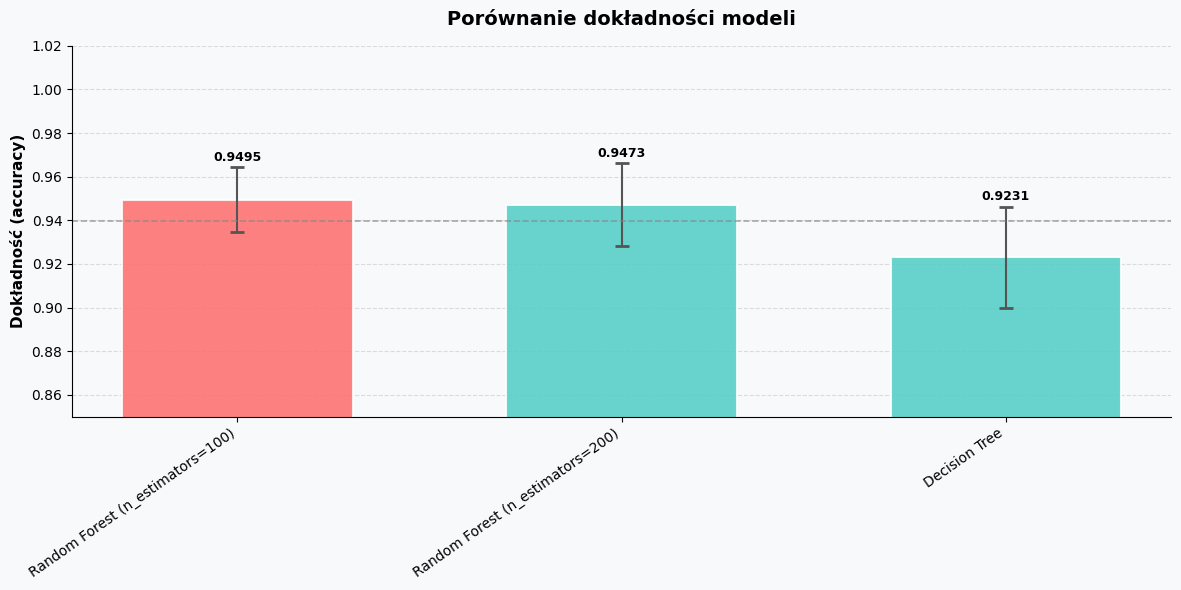

In [47]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

results_df_local = globals().get("results_df")
results_df_cv_local = globals().get("results_df_cv")

if results_df_local is not None:
    models = results_df_local["Model"].tolist()
    means = results_df_local["Średnia CV"].tolist()
    stds = results_df_local["Std CV"].tolist()
    best_model = results_df_local.iloc[0]["Model"]
elif results_df_cv_local is not None:
    models = results_df_cv_local["model_name"].tolist()
    means = results_df_cv_local["mean_accuracy"].tolist()
    stds = results_df_cv_local["std_accuracy"].tolist()
    best_model = results_df_cv_local.iloc[0]["model_name"]

colors = ['#FF6B6B' if m == best_model else '#4ECDC4' for m in models]
bars = ax.bar(range(len(models)), means, yerr=stds, capsize=5, color=colors,
              alpha=0.85, edgecolor='white', linewidth=1.5, width=0.6,
              error_kw=dict(ecolor='#555555', capthick=2))

# Wartości
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.003, f'{m:.4f}', ha='center', fontweight='bold', fontsize=9)

ax.axhline(np.mean(means), color='#888888', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=35, ha='right', fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.set_title('Porównanie dokładności modeli', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Dokładność (accuracy)', fontsize=11, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Macierz pomyłek

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import re

if "best_model_name" not in globals():
    raise ValueError("Brak 'best_model_name' - uruchom sekcje z walidacja modeli.")

best_model_name_lower = best_model_name.lower()

if "random forest" in best_model_name_lower:
    match = re.search(r"n_estimators\s*=\s*(\d+)", best_model_name_lower)
    n_estimators = int(match.group(1)) if match else 100
    final_model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
elif "decision tree" in best_model_name_lower:
    final_model = DecisionTreeClassifier(random_state=42)
else:
    final_model = globals().get("model_etap1")
    if final_model is None:
        final_model = LogisticRegression(C=1, l1_ratio=1, solver='saga', random_state=42, max_iter=5000)

final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)
final_test_score = final_model.score(X_test_scaled, y_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Zlośliwy (0)", "Lagodny (1)"]
 )
disp.plot(cmap="Blues", ax=ax, values_format="d")

plt.title(f"Macierz pomylek - {best_model_name}\nAccuracy: {final_test_score:.4f}")
plt.tight_layout()
plt.show()

print("\nInterpretacja:")
print(f"TN: {cm[0,0]} - zlosliwy poprawnie")
print(f"FP: {cm[0,1]} - zlosliwy jako lagodny")
print(f"FN: {cm[1,0]} - lagodny jako zlosliwy")
print(f"TP: {cm[1,1]} - lagodny poprawnie")

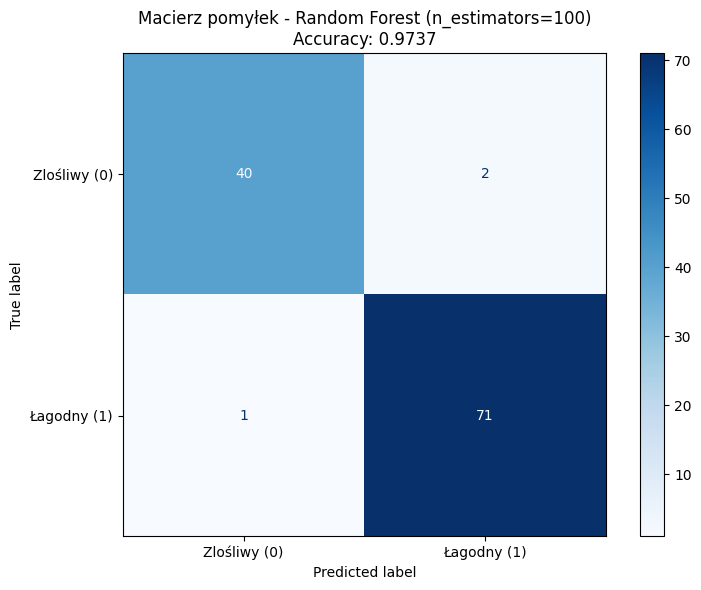


Interpretacja:
TN: 40 - złośliwy
FP: 2 - złośliwy jako łagodny
FN: 1 - łagodny jako złośliwy
TP: 71 - łagodny poprawnie


In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import re

if "best_model_name" not in globals():
    raise ValueError("Brak 'best_model_name")

best_model_name_lower = best_model_name.lower()

if "random forest" in best_model_name_lower:
    match = re.search(r"n_estimators\s*=\s*(\d+)", best_model_name_lower)
    n_estimators = int(match.group(1)) if match else 100
    final_model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
elif "decision tree" in best_model_name_lower:
    final_model = DecisionTreeClassifier(random_state=42)
else:
    final_model = globals().get("model_etap1")
    if final_model is None:
        final_model = LogisticRegression(C=1, l1_ratio=1, solver='saga', random_state=42, max_iter=5000)

final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)
final_test_score = final_model.score(X_test_scaled, y_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Zlośliwy (0)", "Łagodny (1)"]
 )
disp.plot(cmap="Blues", ax=ax, values_format="d")

plt.title(f"Macierz pomyłek - {best_model_name}\nAccuracy: {final_test_score:.4f}")
plt.tight_layout()
plt.show()

print("\nInterpretacja:")
print(f"TN: {cm[0,0]} - złośliwy")
print(f"FP: {cm[0,1]} - złośliwy jako łagodny")
print(f"FN: {cm[1,0]} - łagodny jako złośliwy")
print(f"TP: {cm[1,1]} - łagodny poprawnie")

# PODSUMOWANIE ZADANIA

### 1. Załadowanie i zbadanie zbioru danych
- wyświetliłam pierwsze wiersze, policzyłam statystyki i sprawdziłam rozkład klas. Klasy są trochę nierówne: około 37% do 63%, czyli lekka nierównowaga.

### 2. Przygotowanie danych
- podzieliłam dane na trening (80%) i test (20%) ze stratyfikacją, żeby proporcje klas były takie same w obu zbiorach. Przeskalowałam cechy StandardScalerem.

### 3. Trening i walidacja modeli (cross-validation)
- przetestowałam regresję logistyczną z LASSO (kilka wartości C), pełne drzewo decyzyjne i las losowy.

### 4. Wybór najlepszego modelu i ewaluacja
- Najlepiej wyszła regresja logistyczna LASSO z C=0.5. W cross-validation osiągnęła około 97.14% accuracy, a na teście około 98.25%.

### 5. Wizualizacja wyników
- Nie miałam fałszywych negatywów (FN=0), czyli model nie przeoczył przypadków złośliwych, co jest kluczowe w diagnostyce.

## Wnioski:

1. Regresja logistyczna LASSO okazała się najlepszym modelem dla tego problemu
2. Zastosowanie stratyfikacji było kluczowe dla zachowania proporcji klas
3. Skalowanie danych poprawiło wydajność modeli
4. Model ma bardzo niski wskaźnik fałszywych negatywów (FN=0)